# MDCE Real-Label Multi-Decision Training

This notebook is the strict hard-work step after the pit proof layer. It does not pretend unsupported decisions are trained.

It trains only targets that can be labelled from real public data, compares against baselines, uses temporal validation, writes weak-spot audits, and blocks decision types where labels are missing.


## 1. Mount Drive

Colab requires Drive mount access. The notebook code is folder-locked to `/content/drive/MyDrive/ibm_project_stuff/MDCE` and does not scan the rest of MyDrive.


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install Dependencies


In [2]:
%pip install -q pandas numpy pyarrow scikit-learn matplotlib seaborn joblib


## 3. Run Strict Training

This trains real-label models for stint length and tyre choice when labels are available. It audits safety-car labels and explicitly blocks push/conserve and aggressive/safe strategy until defendable labels exist.


In [3]:
from pathlib import Path
import json
import sqlite3

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


ROOT = Path("/content/drive/MyDrive/ibm_project_stuff/MDCE")
if not ROOT.exists():
    raise FileNotFoundError(
        f"Expected project folder not found: {ROOT}. "
        "This add-on is folder-locked and will not scan MyDrive."
    )

DB_PATH = ROOT / "databases" / "mdce_f1.db"
TRAINING_PATH = ROOT / "data" / "processed" / "pit_training_rows.parquet"
REPORT_DIR = ROOT / "outputs" / "reports"
MODEL_DIR = ROOT / "outputs" / "models"
CHART_DIR = ROOT / "outputs" / "charts"
PROCESSED_DIR = ROOT / "data" / "processed"

for folder in [REPORT_DIR, MODEL_DIR, CHART_DIR, PROCESSED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    print("wrote:", path)


def read_json(path):
    path = Path(path)
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}


def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def multiclass_metrics(y_true, y_pred, model_name, split_name):
    return {
        "model": model_name,
        "split": split_name,
        "rows": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def regression_metrics(y_true, y_pred, model_name, split_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "model": model_name,
        "split": split_name,
        "rows": int(len(y_true)),
        "mae_laps": float(mean_absolute_error(y_true, y_pred)),
        "rmse_laps": float(rmse),
        "r2": float(r2_score(y_true, y_pred)),
    }


def train_multiclass_candidates(train_df, valid_df, test_df, feature_cols, categorical_features, target_col, model_prefix):
    numeric_features = [col for col in feature_cols if col not in categorical_features]
    candidates = {
        f"{model_prefix}_rf_400_leaf3_sqrt_balanced": RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        f"{model_prefix}_rf_700_leaf5_half_balanced": RandomForestClassifier(
            n_estimators=700,
            min_samples_leaf=5,
            max_features=0.5,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        f"{model_prefix}_extra_trees_600_leaf3_sqrt_balanced": ExtraTreesClassifier(
            n_estimators=600,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }
    leaderboard = []
    fitted = {}
    for name, estimator in candidates.items():
        print("validating:", name)
        model = Pipeline(
            steps=[
                ("preprocess", make_preprocessor(numeric_features, categorical_features)),
                ("classifier", estimator),
            ]
        )
        model.fit(train_df[feature_cols], train_df[target_col])
        valid_pred = model.predict(valid_df[feature_cols])
        row = multiclass_metrics(valid_df[target_col], valid_pred, name, "valid_2022")
        leaderboard.append(row)
        fitted[name] = model

    leaderboard_df = pd.DataFrame(leaderboard).sort_values(["macro_f1", "weighted_f1"], ascending=False)
    best_name = leaderboard_df.iloc[0]["model"]
    train_full_df = pd.concat([train_df, valid_df], ignore_index=True)
    best_estimator = clone(candidates[best_name])
    final_model = Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_features, categorical_features)),
            ("classifier", best_estimator),
        ]
    )
    final_model.fit(train_full_df[feature_cols], train_full_df[target_col])
    test_pred = final_model.predict(test_df[feature_cols])
    test_metrics = multiclass_metrics(test_df[target_col], test_pred, best_name, "test_2023")

    majority_class = train_full_df[target_col].mode().iloc[0]
    baseline_pred = np.array([majority_class] * len(test_df))
    baseline_metrics = multiclass_metrics(test_df[target_col], baseline_pred, f"{model_prefix}_majority_baseline", "test_2023")

    predictions = test_df.copy()
    predictions["prediction"] = test_pred
    predictions["correct"] = predictions[target_col].astype(str).eq(pd.Series(test_pred, index=predictions.index).astype(str))

    labels = sorted(pd.Series(pd.concat([train_full_df[target_col], test_df[target_col]], ignore_index=True)).dropna().astype(str).unique())
    report = classification_report(test_df[target_col], test_pred, zero_division=0, output_dict=True)
    cm = confusion_matrix(test_df[target_col], test_pred, labels=labels)

    return {
        "leaderboard": leaderboard_df,
        "best_name": best_name,
        "best_model": final_model,
        "test_metrics": test_metrics,
        "baseline_metrics": baseline_metrics,
        "predictions": predictions,
        "classification_report": report,
        "confusion_matrix": cm,
        "labels": labels,
        "feature_cols": feature_cols,
        "categorical_features": categorical_features,
    }


def train_regression_candidates(train_df, valid_df, test_df, feature_cols, categorical_features, target_col, model_prefix):
    numeric_features = [col for col in feature_cols if col not in categorical_features]
    candidates = {
        f"{model_prefix}_rf_reg_400_leaf3_sqrt": RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        f"{model_prefix}_rf_reg_700_leaf5_half": RandomForestRegressor(
            n_estimators=700,
            min_samples_leaf=5,
            max_features=0.5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        f"{model_prefix}_extra_trees_reg_600_leaf3_sqrt": ExtraTreesRegressor(
            n_estimators=600,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }
    leaderboard = []
    fitted = {}
    for name, estimator in candidates.items():
        print("validating:", name)
        model = Pipeline(
            steps=[
                ("preprocess", make_preprocessor(numeric_features, categorical_features)),
                ("regressor", estimator),
            ]
        )
        model.fit(train_df[feature_cols], train_df[target_col])
        valid_pred = model.predict(valid_df[feature_cols])
        row = regression_metrics(valid_df[target_col], valid_pred, name, "valid_2022")
        leaderboard.append(row)
        fitted[name] = model

    leaderboard_df = pd.DataFrame(leaderboard).sort_values(["mae_laps", "rmse_laps"], ascending=True)
    best_name = leaderboard_df.iloc[0]["model"]

    train_full_df = pd.concat([train_df, valid_df], ignore_index=True)
    best_estimator = clone(candidates[best_name])
    final_model = Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_features, categorical_features)),
            ("regressor", best_estimator),
        ]
    )
    final_model.fit(train_full_df[feature_cols], train_full_df[target_col])
    test_pred = final_model.predict(test_df[feature_cols])
    test_metrics = regression_metrics(test_df[target_col], test_pred, best_name, "test_2023")

    baseline_value = float(train_full_df[target_col].median())
    baseline_pred = np.array([baseline_value] * len(test_df))
    baseline_metrics = regression_metrics(test_df[target_col], baseline_pred, f"{model_prefix}_median_baseline", "test_2023")

    predictions = test_df.copy()
    predictions["prediction_laps_until_next_pit"] = test_pred
    predictions["absolute_error_laps"] = np.abs(predictions[target_col] - predictions["prediction_laps_until_next_pit"])

    return {
        "leaderboard": leaderboard_df,
        "best_name": best_name,
        "best_model": final_model,
        "test_metrics": test_metrics,
        "baseline_metrics": baseline_metrics,
        "predictions": predictions,
        "feature_cols": feature_cols,
        "categorical_features": categorical_features,
    }


def grouped_multiclass_metrics(predictions, group_col, target_col, pred_col="prediction", min_rows=100):
    rows = []
    for value, group in predictions.groupby(group_col):
        if len(group) < min_rows or group[target_col].nunique() < 2:
            continue
        rows.append(
            {
                group_col: value,
                "rows": int(len(group)),
                "class_count": int(group[target_col].nunique()),
                "accuracy": float(accuracy_score(group[target_col], group[pred_col])),
                "balanced_accuracy": float(balanced_accuracy_score(group[target_col], group[pred_col])),
                "macro_f1": float(f1_score(group[target_col], group[pred_col], average="macro", zero_division=0)),
                "weighted_f1": float(f1_score(group[target_col], group[pred_col], average="weighted", zero_division=0)),
            }
        )
    return pd.DataFrame(rows).sort_values(["macro_f1", "rows"], ascending=[True, False]) if rows else pd.DataFrame()


def grouped_regression_metrics(predictions, group_col, target_col, pred_col, min_rows=100):
    rows = []
    for value, group in predictions.groupby(group_col):
        if len(group) < min_rows:
            continue
        rows.append(
            {
                group_col: value,
                "rows": int(len(group)),
                "mae_laps": float(mean_absolute_error(group[target_col], group[pred_col])),
                "rmse_laps": float(np.sqrt(mean_squared_error(group[target_col], group[pred_col]))),
                "r2": float(r2_score(group[target_col], group[pred_col])) if group[target_col].nunique() > 1 else None,
            }
        )
    return pd.DataFrame(rows).sort_values(["mae_laps", "rows"], ascending=[False, False]) if rows else pd.DataFrame()


def promotion_status_classifier(test_metrics, baseline_metrics, min_macro_f1_gain=0.03):
    gain = float(test_metrics["macro_f1"]) - float(baseline_metrics["macro_f1"])
    return {
        "promoted": bool(gain >= min_macro_f1_gain),
        "macro_f1_gain_vs_baseline": gain,
        "gate": f"macro_f1_gain >= {min_macro_f1_gain}",
    }


def promotion_status_regression(test_metrics, baseline_metrics, min_mae_reduction=0.50):
    reduction = float(baseline_metrics["mae_laps"]) - float(test_metrics["mae_laps"])
    return {
        "promoted": bool(reduction >= min_mae_reduction),
        "mae_reduction_vs_baseline": reduction,
        "gate": f"mae_reduction_laps >= {min_mae_reduction}",
    }


def build_tyre_choice_events(db_path):
    conn = sqlite3.connect(db_path)
    laps = pd.read_sql_query(
        """
        SELECT raceId, driverId, lap, milliseconds, year, round, name AS circuit, code AS driver_code,
               Compound, TyreLife, Stint, AirTemp, TrackTemp, Humidity, Pressure, Rainfall,
               WindSpeed, WindDirection, position_x, grid
        FROM kaggle_weather_tyre_laps
        WHERE milliseconds IS NOT NULL AND lap IS NOT NULL AND year IS NOT NULL
        ORDER BY raceId, driverId, lap
        """,
        conn,
    )
    pits = pd.read_sql_query(
        """
        SELECT raceId, driverId, stop, lap AS pit_lap
        FROM jtrotman_pit_stops
        WHERE lap IS NOT NULL
        ORDER BY raceId, driverId, stop
        """,
        conn,
    )
    conn.close()

    numeric_cols = [
        "lap",
        "milliseconds",
        "year",
        "round",
        "TyreLife",
        "Stint",
        "AirTemp",
        "TrackTemp",
        "Humidity",
        "Pressure",
        "Rainfall",
        "WindSpeed",
        "WindDirection",
        "position_x",
        "grid",
    ]
    for col in numeric_cols:
        laps[col] = pd.to_numeric(laps[col], errors="coerce")
    pits["pit_lap"] = pd.to_numeric(pits["pit_lap"], errors="coerce")

    laps["lap_time_s"] = laps["milliseconds"] / 1000.0
    laps["current_compound"] = laps["Compound"].fillna("UNKNOWN").astype(str).str.upper()
    laps["driver_code"] = laps["driver_code"].fillna("UNK").astype(str).str.upper()
    laps["circuit"] = laps["circuit"].fillna("UNKNOWN").astype(str)
    laps = laps.dropna(subset=["raceId", "driverId", "lap", "lap_time_s", "year"]).sort_values(["raceId", "driverId", "lap"])

    group_features = []
    for (_, _), group in laps.groupby(["raceId", "driverId"], sort=False):
        group = group.sort_values("lap").copy()
        group["rolling_lap_avg_3"] = group["lap_time_s"].rolling(3, min_periods=1).mean()
        group["rolling_lap_avg_5"] = group["lap_time_s"].rolling(5, min_periods=1).mean()
        group["lap_time_delta"] = group["lap_time_s"].diff().fillna(0)
        group["degradation_3"] = ((group["lap_time_s"] - group["lap_time_s"].shift(3)) / 3).fillna(0)
        group["degradation_5"] = ((group["lap_time_s"] - group["lap_time_s"].shift(5)) / 5).fillna(0)
        group["lap_progress_ratio"] = group["lap"] / group["lap"].max()
        group_features.append(group)
    laps = pd.concat(group_features, ignore_index=True)

    events = []
    pit_lookup = pits.dropna(subset=["pit_lap"]).groupby(["raceId", "driverId"])
    for (race_id, driver_id), pit_group in pit_lookup:
        driver_laps = laps[(laps["raceId"].eq(race_id)) & (laps["driverId"].eq(driver_id))].sort_values("lap")
        if driver_laps.empty:
            continue
        for _, pit in pit_group.iterrows():
            pit_lap = int(pit["pit_lap"])
            pre_rows = driver_laps[driver_laps["lap"] <= pit_lap]
            post_rows = driver_laps[driver_laps["lap"] > pit_lap]
            if pre_rows.empty or post_rows.empty:
                continue
            pre = pre_rows.iloc[-1]
            post = post_rows.iloc[0]
            next_compound = str(post["current_compound"]).upper()
            if next_compound in ["", "NAN", "\\N", "UNKNOWN"]:
                continue
            events.append(
                {
                    "raceId": int(race_id),
                    "driverId": int(driver_id),
                    "year": int(pre["year"]),
                    "round": int(pre["round"]),
                    "circuit": str(pre["circuit"]),
                    "driver_code": str(pre["driver_code"]),
                    "pit_stop_number": int(pit["stop"]) if pd.notna(pit["stop"]) else np.nan,
                    "decision_lap": int(pre["lap"]),
                    "target_next_compound": next_compound,
                    "current_compound": str(pre["current_compound"]),
                    "tyre_age": float(pre["TyreLife"]) if pd.notna(pre["TyreLife"]) else np.nan,
                    "current_stint": float(pre["Stint"]) if pd.notna(pre["Stint"]) else np.nan,
                    "lap_time_s": float(pre["lap_time_s"]),
                    "position": float(pre["position_x"]) if pd.notna(pre["position_x"]) else np.nan,
                    "grid": float(pre["grid"]) if pd.notna(pre["grid"]) else np.nan,
                    "air_temp": float(pre["AirTemp"]) if pd.notna(pre["AirTemp"]) else np.nan,
                    "track_temp": float(pre["TrackTemp"]) if pd.notna(pre["TrackTemp"]) else np.nan,
                    "humidity": float(pre["Humidity"]) if pd.notna(pre["Humidity"]) else np.nan,
                    "pressure": float(pre["Pressure"]) if pd.notna(pre["Pressure"]) else np.nan,
                    "rainfall": float(pre["Rainfall"]) if pd.notna(pre["Rainfall"]) else np.nan,
                    "wind_speed": float(pre["WindSpeed"]) if pd.notna(pre["WindSpeed"]) else np.nan,
                    "wind_direction": float(pre["WindDirection"]) if pd.notna(pre["WindDirection"]) else np.nan,
                    "rolling_lap_avg_3": float(pre["rolling_lap_avg_3"]),
                    "rolling_lap_avg_5": float(pre["rolling_lap_avg_5"]),
                    "lap_time_delta": float(pre["lap_time_delta"]),
                    "degradation_3": float(pre["degradation_3"]),
                    "degradation_5": float(pre["degradation_5"]),
                    "lap_progress_ratio": float(pre["lap_progress_ratio"]),
                }
            )
    return pd.DataFrame(events)


def audit_safety_car_schema(db_path):
    conn = sqlite3.connect(db_path)
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
    rows = []
    for table_name in tables["name"].astype(str):
        lower_name = table_name.lower()
        if not any(token in lower_name for token in ["safety", "risk", "mendeley", "track_status", "status"]):
            continue
        try:
            columns = pd.read_sql_query(f'PRAGMA table_info("{table_name}")', conn)
            count = pd.read_sql_query(f'SELECT COUNT(*) AS rows FROM "{table_name}"', conn).iloc[0]["rows"]
        except Exception as exc:
            rows.append({"table": table_name, "status": "schema_read_failed", "error": str(exc)})
            continue
        column_names = columns["name"].astype(str).tolist()
        candidate_label_cols = [
            col
            for col in column_names
            if any(token in col.lower() for token in ["safety", "safetycar", "track_status", "trackstatus", "vsc", "risk", "sc"])
        ]
        rows.append(
            {
                "table": table_name,
                "rows": int(count),
                "column_count": int(len(column_names)),
                "candidate_label_columns": ", ".join(candidate_label_cols),
                "status": "candidate_columns_found" if candidate_label_cols else "no_obvious_label_column",
            }
        )
    conn.close()
    return pd.DataFrame(rows)


print("STEP 1: load training table")
if not TRAINING_PATH.exists():
    raise FileNotFoundError(f"Missing training table: {TRAINING_PATH}. Run the main notebook first.")
training = pd.read_parquet(TRAINING_PATH)
print("training shape:", training.shape)

feature_cols_stint = [
    "lap",
    "lap_time_s",
    "position",
    "grid",
    "tyre_age",
    "stint",
    "air_temp",
    "track_temp",
    "humidity",
    "pressure",
    "rainfall",
    "wind_speed",
    "wind_direction",
    "rolling_lap_avg_3",
    "rolling_lap_avg_5",
    "lap_time_delta",
    "degradation_3",
    "degradation_5",
    "lap_progress_ratio",
    "tyre_compound",
]
categorical_stint = ["tyre_compound"]

needed = set(feature_cols_stint + ["year", "laps_until_next_pit"])
missing = sorted(needed - set(training.columns))
if missing:
    raise ValueError(f"Training table is missing required columns: {missing}")

stint_df = training.dropna(subset=["year", "laps_until_next_pit"]).copy()
stint_df["laps_until_next_pit_clipped"] = pd.to_numeric(stint_df["laps_until_next_pit"], errors="coerce").clip(lower=0, upper=25)
stint_df = stint_df.dropna(subset=["laps_until_next_pit_clipped"]).copy()

conditions = [
    stint_df["laps_until_next_pit_clipped"] <= 1,
    stint_df["laps_until_next_pit_clipped"].between(2, 3),
    stint_df["laps_until_next_pit_clipped"].between(4, 7),
    stint_df["laps_until_next_pit_clipped"] >= 8,
]
choices = ["pit_now_or_next_lap", "pit_window_2_3_laps", "extend_4_7_laps", "long_extend_8_plus_laps"]
stint_df["stint_action_bucket"] = np.select(conditions, choices, default="unknown")
stint_df = stint_df[stint_df["stint_action_bucket"].ne("unknown")].copy()

train_2021 = stint_df[stint_df["year"].eq(2021)].copy()
valid_2022 = stint_df[stint_df["year"].eq(2022)].copy()
test_2023 = stint_df[stint_df["year"].eq(2023)].copy()
if train_2021.empty or valid_2022.empty or test_2023.empty:
    raise RuntimeError("Need 2021 train, 2022 validation, and 2023 test rows for strict temporal evaluation.")

print("STEP 2: train stint action classifier")
stint_classifier = train_multiclass_candidates(
    train_2021,
    valid_2022,
    test_2023,
    feature_cols_stint,
    categorical_stint,
    "stint_action_bucket",
    "stint_action",
)
joblib.dump(stint_classifier["best_model"], MODEL_DIR / "stint_action_classifier.joblib")
stint_classifier["leaderboard"].to_csv(REPORT_DIR / "stint_action_validation_leaderboard.csv", index=False)
stint_classifier["predictions"].to_csv(REPORT_DIR / "stint_action_predictions_2023.csv", index=False)
stint_classifier_gate = promotion_status_classifier(stint_classifier["test_metrics"], stint_classifier["baseline_metrics"])
stint_action_circuit_metrics = grouped_multiclass_metrics(stint_classifier["predictions"], "circuit", "stint_action_bucket")
stint_action_driver_metrics = grouped_multiclass_metrics(stint_classifier["predictions"], "driver_code", "stint_action_bucket")
stint_action_circuit_metrics.to_csv(REPORT_DIR / "stint_action_circuit_metrics_2023.csv", index=False)
stint_action_driver_metrics.to_csv(REPORT_DIR / "stint_action_driver_metrics_2023.csv", index=False)
write_json(
    REPORT_DIR / "stint_action_model_metrics.json",
    {
        "best_model": stint_classifier["best_name"],
        "promotion_gate": stint_classifier_gate,
        "feature_set": feature_cols_stint,
        "categorical_features": categorical_stint,
        "validation_leaderboard": stint_classifier["leaderboard"].to_dict(orient="records"),
        "test_metrics": stint_classifier["test_metrics"],
        "baseline_metrics": stint_classifier["baseline_metrics"],
        "classification_report": stint_classifier["classification_report"],
        "labels": stint_classifier["labels"],
        "safe_claim": "This predicts actual observed public-data stint action buckets, not globally optimal strategy.",
    },
)

print("STEP 3: train stint remaining-laps regressor")
stint_regression = train_regression_candidates(
    train_2021,
    valid_2022,
    test_2023,
    feature_cols_stint,
    categorical_stint,
    "laps_until_next_pit_clipped",
    "stint_remaining",
)
joblib.dump(stint_regression["best_model"], MODEL_DIR / "stint_remaining_regressor.joblib")
stint_regression["leaderboard"].to_csv(REPORT_DIR / "stint_remaining_validation_leaderboard.csv", index=False)
stint_regression["predictions"].to_csv(REPORT_DIR / "stint_remaining_predictions_2023.csv", index=False)
stint_regression_gate = promotion_status_regression(stint_regression["test_metrics"], stint_regression["baseline_metrics"])
stint_remaining_circuit_metrics = grouped_regression_metrics(
    stint_regression["predictions"],
    "circuit",
    "laps_until_next_pit_clipped",
    "prediction_laps_until_next_pit",
)
stint_remaining_driver_metrics = grouped_regression_metrics(
    stint_regression["predictions"],
    "driver_code",
    "laps_until_next_pit_clipped",
    "prediction_laps_until_next_pit",
)
stint_remaining_circuit_metrics.to_csv(REPORT_DIR / "stint_remaining_circuit_metrics_2023.csv", index=False)
stint_remaining_driver_metrics.to_csv(REPORT_DIR / "stint_remaining_driver_metrics_2023.csv", index=False)
write_json(
    REPORT_DIR / "stint_remaining_model_metrics.json",
    {
        "best_model": stint_regression["best_name"],
        "promotion_gate": stint_regression_gate,
        "feature_set": feature_cols_stint,
        "categorical_features": categorical_stint,
        "validation_leaderboard": stint_regression["leaderboard"].to_dict(orient="records"),
        "test_metrics": stint_regression["test_metrics"],
        "baseline_metrics": stint_regression["baseline_metrics"],
        "safe_claim": "This estimates actual observed laps until next pit from public data; it is not an optimal strategy simulator.",
    },
)

print("STEP 4: build tyre choice event labels")
if not DB_PATH.exists():
    raise FileNotFoundError(f"Missing database: {DB_PATH}")
tyre_events = build_tyre_choice_events(DB_PATH)
tyre_events.to_parquet(PROCESSED_DIR / "tyre_choice_training_events.parquet", index=False)
tyre_events.to_csv(REPORT_DIR / "tyre_choice_training_events.csv", index=False)
print("tyre choice event shape:", tyre_events.shape)
print("tyre target distribution:")
print(tyre_events["target_next_compound"].value_counts(dropna=False).to_string())

min_target_count = tyre_events["target_next_compound"].value_counts().min() if not tyre_events.empty else 0
tyre_choice_result = None
tyre_choice_gate = None
tyre_choice_circuit_metrics = pd.DataFrame()
tyre_choice_driver_metrics = pd.DataFrame()
if tyre_events.empty or tyre_events["year"].nunique() < 3 or min_target_count < 5:
    tyre_choice_status = "not_enough_labelled_events_for_strict_temporal_training"
    print("tyre choice training skipped:", tyre_choice_status)
else:
    feature_cols_tyre = [
        "decision_lap",
        "pit_stop_number",
        "lap_time_s",
        "position",
        "grid",
        "tyre_age",
        "current_stint",
        "air_temp",
        "track_temp",
        "humidity",
        "pressure",
        "rainfall",
        "wind_speed",
        "wind_direction",
        "rolling_lap_avg_3",
        "rolling_lap_avg_5",
        "lap_time_delta",
        "degradation_3",
        "degradation_5",
        "lap_progress_ratio",
        "current_compound",
    ]
    categorical_tyre = ["current_compound"]
    train_tyre = tyre_events[tyre_events["year"].eq(2021)].copy()
    valid_tyre = tyre_events[tyre_events["year"].eq(2022)].copy()
    test_tyre = tyre_events[tyre_events["year"].eq(2023)].copy()
    if train_tyre.empty or valid_tyre.empty or test_tyre.empty:
        tyre_choice_status = "missing_temporal_split_for_tyre_choice"
        print("tyre choice training skipped:", tyre_choice_status)
    else:
        print("STEP 5: train tyre choice classifier")
        tyre_choice_result = train_multiclass_candidates(
            train_tyre,
            valid_tyre,
            test_tyre,
            feature_cols_tyre,
            categorical_tyre,
            "target_next_compound",
            "tyre_choice",
        )
        tyre_choice_status = "trained_with_actual_post_pit_compound_labels"
        joblib.dump(tyre_choice_result["best_model"], MODEL_DIR / "tyre_choice_classifier.joblib")
        tyre_choice_result["leaderboard"].to_csv(REPORT_DIR / "tyre_choice_validation_leaderboard.csv", index=False)
        tyre_choice_result["predictions"].to_csv(REPORT_DIR / "tyre_choice_predictions_2023.csv", index=False)
        tyre_choice_gate = promotion_status_classifier(tyre_choice_result["test_metrics"], tyre_choice_result["baseline_metrics"])
        tyre_choice_circuit_metrics = grouped_multiclass_metrics(tyre_choice_result["predictions"], "circuit", "target_next_compound", min_rows=10)
        tyre_choice_driver_metrics = grouped_multiclass_metrics(tyre_choice_result["predictions"], "driver_code", "target_next_compound", min_rows=10)
        tyre_choice_circuit_metrics.to_csv(REPORT_DIR / "tyre_choice_circuit_metrics_2023.csv", index=False)
        tyre_choice_driver_metrics.to_csv(REPORT_DIR / "tyre_choice_driver_metrics_2023.csv", index=False)
        write_json(
            REPORT_DIR / "tyre_choice_model_metrics.json",
            {
                "best_model": tyre_choice_result["best_name"],
                "promotion_gate": tyre_choice_gate,
                "feature_set": feature_cols_tyre,
                "categorical_features": categorical_tyre,
                "validation_leaderboard": tyre_choice_result["leaderboard"].to_dict(orient="records"),
                "test_metrics": tyre_choice_result["test_metrics"],
                "baseline_metrics": tyre_choice_result["baseline_metrics"],
                "classification_report": tyre_choice_result["classification_report"],
                "labels": tyre_choice_result["labels"],
                "safe_claim": "This predicts actual next compound selected after pit stops in public data. It does not prove the compound was strategically optimal.",
            },
        )

print("STEP 6: audit safety-car/risk labels")
safety_audit = audit_safety_car_schema(DB_PATH)
safety_audit.to_csv(REPORT_DIR / "safety_car_label_schema_audit.csv", index=False)
write_json(REPORT_DIR / "safety_car_label_schema_audit.json", safety_audit.to_dict(orient="records"))
print(safety_audit.head(20).to_string(index=False))

print("STEP 7: charts and final strict registry")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    stint_classifier["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=stint_classifier["labels"],
    yticklabels=stint_classifier["labels"],
    ax=axes[0],
)
axes[0].set_title("Stint Action Classifier: 2023 Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

if tyre_choice_result is not None:
    sns.heatmap(
        tyre_choice_result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=tyre_choice_result["labels"],
        yticklabels=tyre_choice_result["labels"],
        ax=axes[1],
    )
    axes[1].set_title("Tyre Choice Classifier: 2023 Confusion Matrix")
else:
    axes[1].axis("off")
    axes[1].text(0.05, 0.5, "Tyre choice model not trained:\\ninsufficient strict temporal labels", fontsize=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(CHART_DIR / "real_multidecision_confusion_matrices.png", dpi=160)
plt.close()

plt.figure(figsize=(8, 5))
sample = stint_regression["predictions"].sample(min(3000, len(stint_regression["predictions"])), random_state=RANDOM_STATE)
plt.scatter(sample["laps_until_next_pit_clipped"], sample["prediction_laps_until_next_pit"], alpha=0.25, s=12)
plt.plot([0, 25], [0, 25], color="red", linestyle="--")
plt.xlabel("Actual laps until next pit")
plt.ylabel("Predicted laps until next pit")
plt.title("Stint Remaining Regressor: 2023 Holdout")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "stint_remaining_regression_holdout.png", dpi=160)
plt.close()

pit_final = read_json(REPORT_DIR / "pit_final_model_decision.json").get("selected_model", {})
pit_metrics_2023 = pit_final.get("metrics_2023", {})
pit_model_path = pit_final.get("path") or str(MODEL_DIR / "pit_window_challenger_best_model.joblib")
pit_f1 = pit_metrics_2023.get("f1")

registry_rows = [
    {
        "decision_type": "pit_timing",
        "status": "trained_and_finalized",
        "model_path": pit_model_path,
        "label_source": "actual pit stop labels",
        "test_protocol": "2023 holdout; threshold from 2022 validation",
        "primary_metric": "F1",
        "primary_metric_value": pit_f1,
        "safe_claim": "Public-data pit-window confidence model, not private optimal strategy.",
    },
    {
        "decision_type": "stint_length",
        "status": "promoted_actual_next_pit_horizon" if stint_classifier_gate["promoted"] else "trained_not_promoted_baseline_gate_failed",
        "model_path": str(MODEL_DIR / "stint_action_classifier.joblib"),
        "label_source": "actual laps until next pit bucket",
        "test_protocol": "2021 train, 2022 validation, 2023 holdout",
        "primary_metric": "macro_f1",
        "primary_metric_value": stint_classifier["test_metrics"]["macro_f1"],
        "safe_claim": "Predicts observed stint horizon behavior, not guaranteed optimal stint length.",
    },
    {
        "decision_type": "stint_remaining_regression",
        "status": "promoted_actual_laps_until_next_pit" if stint_regression_gate["promoted"] else "trained_not_promoted_baseline_gate_failed",
        "model_path": str(MODEL_DIR / "stint_remaining_regressor.joblib"),
        "label_source": "actual laps until next pit",
        "test_protocol": "2021 train, 2022 validation, 2023 holdout",
        "primary_metric": "mae_laps",
        "primary_metric_value": stint_regression["test_metrics"]["mae_laps"],
        "safe_claim": "Estimates public-data observed remaining stint length.",
    },
    {
        "decision_type": "tyre_choice",
        "status": (
            "promoted_actual_post_pit_compound_labels"
            if tyre_choice_gate and tyre_choice_gate["promoted"]
            else "trained_not_promoted_baseline_gate_failed"
            if tyre_choice_gate
            else tyre_choice_status
        ),
        "model_path": str(MODEL_DIR / "tyre_choice_classifier.joblib") if tyre_choice_result is not None else "",
        "label_source": "actual compound on first lap after pit stop",
        "test_protocol": "2021 train, 2022 validation, 2023 holdout" if tyre_choice_result is not None else "not trained",
        "primary_metric": "macro_f1" if tyre_choice_result is not None else "",
        "primary_metric_value": tyre_choice_result["test_metrics"]["macro_f1"] if tyre_choice_result is not None else None,
        "safe_claim": "Predicts observed next compound, not proven optimal tyre choice.",
    },
    {
        "decision_type": "push_conserve",
        "status": "not_trained_label_blocked",
        "model_path": "",
        "label_source": "missing explicit push/conserve command or intent labels",
        "test_protocol": "blocked",
        "primary_metric": "",
        "primary_metric_value": None,
        "safe_claim": "Do not claim trained push/conserve decisions until labels exist.",
    },
    {
        "decision_type": "safety_car_response",
        "status": "schema_audited_needs_label_mapping",
        "model_path": "",
        "label_source": "candidate safety/risk tables audited",
        "test_protocol": "schema audit only",
        "primary_metric": "",
        "primary_metric_value": None,
        "safe_claim": "Do not claim trained safety-car response until lap-level labels are mapped and validated.",
    },
    {
        "decision_type": "aggressive_safe_strategy",
        "status": "not_trained_label_blocked",
        "model_path": "",
        "label_source": "missing objective outcome labels for aggressive/safe strategy",
        "test_protocol": "blocked",
        "primary_metric": "",
        "primary_metric_value": None,
        "safe_claim": "Do not claim trained aggressive/safe strategy until outcome labels exist.",
    },
]
registry_df = pd.DataFrame(registry_rows)
registry_df.to_csv(REPORT_DIR / "mdce_real_decision_training_registry.csv", index=False)

summary = {
    "project": "MDCE strict real-label multi-decision training",
    "principle": "Train only decisions with defensible labels; explicitly block unsupported targets.",
    "stint_action": {
        "best_model": stint_classifier["best_name"],
        "promotion_gate": stint_classifier_gate,
        "test_metrics": stint_classifier["test_metrics"],
        "baseline_metrics": stint_classifier["baseline_metrics"],
        "weakest_circuits": stint_action_circuit_metrics.head(10).to_dict(orient="records"),
        "weakest_drivers": stint_action_driver_metrics.head(10).to_dict(orient="records"),
    },
    "stint_remaining_regression": {
        "best_model": stint_regression["best_name"],
        "promotion_gate": stint_regression_gate,
        "test_metrics": stint_regression["test_metrics"],
        "baseline_metrics": stint_regression["baseline_metrics"],
        "highest_error_circuits": stint_remaining_circuit_metrics.head(10).to_dict(orient="records"),
        "highest_error_drivers": stint_remaining_driver_metrics.head(10).to_dict(orient="records"),
    },
    "tyre_choice": {
        "status": tyre_choice_status,
        "best_model": tyre_choice_result["best_name"] if tyre_choice_result is not None else None,
        "promotion_gate": tyre_choice_gate,
        "test_metrics": tyre_choice_result["test_metrics"] if tyre_choice_result is not None else None,
        "baseline_metrics": tyre_choice_result["baseline_metrics"] if tyre_choice_result is not None else None,
        "weakest_circuits": tyre_choice_circuit_metrics.head(10).to_dict(orient="records"),
        "weakest_drivers": tyre_choice_driver_metrics.head(10).to_dict(orient="records"),
        "event_rows": int(len(tyre_events)),
    },
    "safety_car_schema_audit_rows": int(len(safety_audit)),
    "registry": registry_rows,
}
write_json(REPORT_DIR / "mdce_real_multidecision_training_summary.json", summary)

lines = [
    "# MDCE Real-Label Multi-Decision Training",
    "",
    "## Principle",
    "",
    "This add-on does not use shortcut labels. It trains only decision types where the current public dataset provides defensible labels, and blocks the rest until stronger labels exist.",
    "",
    "## Trained Decision Layers",
    "",
    "### Stint Length",
    "",
    f"- Classifier model: `{stint_classifier['best_name']}`",
    f"- Model path: `{MODEL_DIR / 'stint_action_classifier.joblib'}`",
    f"- 2023 macro F1: `{stint_classifier['test_metrics']['macro_f1']:.3f}`",
    f"- 2023 weighted F1: `{stint_classifier['test_metrics']['weighted_f1']:.3f}`",
    f"- Baseline macro F1: `{stint_classifier['baseline_metrics']['macro_f1']:.3f}`",
    f"- Promotion gate: `{stint_classifier_gate['gate']}`",
    f"- Macro F1 gain vs baseline: `{stint_classifier_gate['macro_f1_gain_vs_baseline']:.3f}`",
    f"- Promoted: `{stint_classifier_gate['promoted']}`",
    "- Claim: predicts observed next-pit horizon buckets, not guaranteed optimal stint length.",
    "",
    "### Stint Remaining Regression",
    "",
    f"- Regressor model: `{stint_regression['best_name']}`",
    f"- Model path: `{MODEL_DIR / 'stint_remaining_regressor.joblib'}`",
    f"- 2023 MAE: `{stint_regression['test_metrics']['mae_laps']:.3f}` laps",
    f"- Baseline MAE: `{stint_regression['baseline_metrics']['mae_laps']:.3f}` laps",
    f"- Promotion gate: `{stint_regression_gate['gate']}`",
    f"- MAE reduction vs baseline: `{stint_regression_gate['mae_reduction_vs_baseline']:.3f}` laps",
    f"- Promoted: `{stint_regression_gate['promoted']}`",
    "- Claim: estimates observed laps until next pit from public data.",
    "",
    "### Tyre Choice",
    "",
    f"- Status: `{tyre_choice_status}`",
    f"- Labelled tyre events: `{len(tyre_events)}`",
]
if tyre_choice_result is not None:
    lines += [
        f"- Classifier model: `{tyre_choice_result['best_name']}`",
        f"- Model path: `{MODEL_DIR / 'tyre_choice_classifier.joblib'}`",
        f"- 2023 macro F1: `{tyre_choice_result['test_metrics']['macro_f1']:.3f}`",
        f"- 2023 weighted F1: `{tyre_choice_result['test_metrics']['weighted_f1']:.3f}`",
        f"- Baseline macro F1: `{tyre_choice_result['baseline_metrics']['macro_f1']:.3f}`",
        f"- Promotion gate: `{tyre_choice_gate['gate']}`",
        f"- Macro F1 gain vs baseline: `{tyre_choice_gate['macro_f1_gain_vs_baseline']:.3f}`",
        f"- Promoted: `{tyre_choice_gate['promoted']}`",
        "- Claim: predicts observed next compound after a pit stop, not proven optimal compound choice.",
    ]
else:
    lines.append("- Claim: not trained because strict temporal label requirements were not met.")

lines += [
    "",
    "## Blocked Or Limited Decision Layers",
    "",
    "- `push_conserve`: blocked because explicit command/intent labels are not present.",
    "- `safety_car_response`: schema audited, but lap-level safety-car/VSC response labels must be mapped before training claims.",
    "- `aggressive_safe_strategy`: blocked because objective aggressive/safe outcome labels are not present.",
    "",
    "## Weak-Spot Audits",
    "",
    "These are not hidden. They are where the next iteration should focus.",
    "",
    "### Stint Action: Lowest Circuit Macro F1",
    "",
]
if stint_action_circuit_metrics.empty:
    lines.append("- Not enough grouped rows.")
else:
    for _, row in stint_action_circuit_metrics.head(10).iterrows():
        lines.append(f"- `{row['circuit']}`: macro F1 `{row['macro_f1']:.3f}`, rows `{int(row['rows'])}`")

lines += [
    "",
    "### Stint Remaining: Highest Circuit MAE",
    "",
]
if stint_remaining_circuit_metrics.empty:
    lines.append("- Not enough grouped rows.")
else:
    for _, row in stint_remaining_circuit_metrics.head(10).iterrows():
        lines.append(f"- `{row['circuit']}`: MAE `{row['mae_laps']:.3f}` laps, rows `{int(row['rows'])}`")

lines += [
    "",
    "## Decision Training Registry",
    "",
    "| Decision Type | Status | Label Source | Primary Metric | Value | Safe Claim |",
    "|---|---|---|---|---:|---|",
]
for row in registry_rows:
    value = "" if row["primary_metric_value"] is None else f"{float(row['primary_metric_value']):.3f}"
    lines.append(
        f"| {row['decision_type']} | {row['status']} | {row['label_source']} | {row['primary_metric']} | {value} | {row['safe_claim']} |"
    )
lines += [
    "",
    "## Files Written",
    "",
    f"- `{REPORT_DIR / 'mdce_real_decision_training_registry.csv'}`",
    f"- `{REPORT_DIR / 'mdce_real_multidecision_training_summary.json'}`",
    f"- `{REPORT_DIR / 'stint_action_model_metrics.json'}`",
    f"- `{REPORT_DIR / 'stint_action_circuit_metrics_2023.csv'}`",
    f"- `{REPORT_DIR / 'stint_action_driver_metrics_2023.csv'}`",
    f"- `{REPORT_DIR / 'stint_remaining_model_metrics.json'}`",
    f"- `{REPORT_DIR / 'stint_remaining_circuit_metrics_2023.csv'}`",
    f"- `{REPORT_DIR / 'stint_remaining_driver_metrics_2023.csv'}`",
    f"- `{REPORT_DIR / 'tyre_choice_model_metrics.json'}`",
    f"- `{REPORT_DIR / 'tyre_choice_circuit_metrics_2023.csv'}` if trained",
    f"- `{REPORT_DIR / 'tyre_choice_driver_metrics_2023.csv'}` if trained",
    f"- `{REPORT_DIR / 'safety_car_label_schema_audit.csv'}`",
    f"- `{CHART_DIR / 'real_multidecision_confusion_matrices.png'}`",
    f"- `{CHART_DIR / 'stint_remaining_regression_holdout.png'}`",
]
(REPORT_DIR / "mdce_real_multidecision_training_summary.md").write_text("\n".join(lines), encoding="utf-8")

print("REAL MULTIDECISION TRAINING COMPLETE")
print("Stint action model:", stint_classifier["best_name"])
print("Stint action macro F1:", round(stint_classifier["test_metrics"]["macro_f1"], 4))
print("Stint remaining MAE:", round(stint_regression["test_metrics"]["mae_laps"], 4))
print("Tyre choice status:", tyre_choice_status)
if tyre_choice_result is not None:
    print("Tyre choice model:", tyre_choice_result["best_name"])
    print("Tyre choice macro F1:", round(tyre_choice_result["test_metrics"]["macro_f1"], 4))
print("Report:", REPORT_DIR / "mdce_real_multidecision_training_summary.md")


STEP 1: load training table
training shape: (40867, 32)
STEP 2: train stint action classifier
validating: stint_action_rf_400_leaf3_sqrt_balanced
validating: stint_action_rf_700_leaf5_half_balanced
validating: stint_action_extra_trees_600_leaf3_sqrt_balanced
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_action_model_metrics.json
STEP 3: train stint remaining-laps regressor
validating: stint_remaining_rf_reg_400_leaf3_sqrt
validating: stint_remaining_rf_reg_700_leaf5_half
validating: stint_remaining_extra_trees_reg_600_leaf3_sqrt
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_remaining_model_metrics.json
STEP 4: build tyre choice event labels
tyre choice event shape: (2436, 28)
tyre target distribution:
target_next_compound
HARD            1041
MEDIUM           731
SOFT             451
INTERMEDIATE     179
WET               25
NONE               9
STEP 5: train tyre choice classifier
validating: tyre_choice_rf_400_leaf3_sqrt_balan

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/tyre_choice_model_metrics.json
STEP 6: audit safety-car/risk labels
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/safety_car_label_schema_audit.json
                                                                                                             table  rows  column_count                         candidate_label_columns                  status
                                                                                                   jtrotman_status   140             2                                                 no_obvious_label_column
mendeley_data_raw_extracted_mendeley_safety_car_multi_season_formula_1_lap_dataset_with_race_contr_f1_saf_026321a5  1310            29                 TrackStatus, IsSafetyCar, IsVSC candidate_columns_found
mendeley_data_raw_extracted_mendeley_safety_car_multi_season_formula_1_lap_dataset_with_race_contr_f1_saf_0539bcdb  1229            29    

## 4. View Outputs


Summary: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_real_multidecision_training_summary.md
Registry: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_real_decision_training_registry.csv


# MDCE Real-Label Multi-Decision Training

## Principle

This add-on does not use shortcut labels. It trains only decision types where the current public dataset provides defensible labels, and blocks the rest until stronger labels exist.

## Trained Decision Layers

### Stint Length

- Classifier model: `stint_action_rf_700_leaf5_half_balanced`
- Model path: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/stint_action_classifier.joblib`
- 2023 macro F1: `0.723`
- 2023 weighted F1: `0.784`
- Baseline macro F1: `0.184`
- Promotion gate: `macro_f1_gain >= 0.03`
- Macro F1 gain vs baseline: `0.539`
- Promoted: `True`
- Claim: predicts observed next-pit horizon buckets, not guaranteed optimal stint length.

### Stint Remaining Regression

- Regressor model: `stint_remaining_rf_reg_700_leaf5_half`
- Model path: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/stint_remaining_regressor.joblib`
- 2023 MAE: `3.765` laps
- Baseline MAE: `6.546` laps
- Promotion gate: `mae_reduction_laps >= 0.5`
- MAE reduction vs baseline: `2.780` laps
- Promoted: `True`
- Claim: estimates observed laps until next pit from public data.

### Tyre Choice

- Status: `trained_with_actual_post_pit_compound_labels`
- Labelled tyre events: `2436`
- Classifier model: `tyre_choice_extra_trees_600_leaf3_sqrt_balanced`
- Model path: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/tyre_choice_classifier.joblib`
- 2023 macro F1: `0.306`
- 2023 weighted F1: `0.496`
- Baseline macro F1: `0.125`
- Promotion gate: `macro_f1_gain >= 0.03`
- Macro F1 gain vs baseline: `0.181`
- Promoted: `True`
- Claim: predicts observed next compound after a pit stop, not proven optimal compound choice.

## Blocked Or Limited Decision Layers

- `push_conserve`: blocked because explicit command/intent labels are not present.
- `safety_car_response`: schema audited, but lap-level safety-car/VSC response labels must be mapped before training claims.
- `aggressive_safe_strategy`: blocked because objective aggressive/safe outcome labels are not present.

## Weak-Spot Audits

These are not hidden. They are where the next iteration should focus.

### Stint Action: Lowest Circuit Macro F1

- `Circuit Park Zandvoort`: macro F1 `0.443`, rows `1162`
- `Albert Park Grand Prix Circuit`: macro F1 `0.526`, rows `920`
- `Losail International Circuit`: macro F1 `0.649`, rows `762`
- `Circuit of the Americas`: macro F1 `0.677`, rows `640`
- `Suzuka Circuit`: macro F1 `0.688`, rows `545`
- `Red Bull Ring`: macro F1 `0.690`, rows `845`
- `Bahrain International Circuit`: macro F1 `0.701`, rows `695`
- `Autódromo Hermanos Rodríguez`: macro F1 `0.711`, rows `635`
- `Circuit de Spa-Francorchamps`: macro F1 `0.720`, rows `483`
- `Autódromo José Carlos Pace`: macro F1 `0.737`, rows `784`

### Stint Remaining: Highest Circuit MAE

- `Albert Park Grand Prix Circuit`: MAE `7.028` laps, rows `920`
- `Circuit Park Zandvoort`: MAE `5.793` laps, rows `1162`
- `Silverstone Circuit`: MAE `5.059` laps, rows `562`
- `Red Bull Ring`: MAE `4.788` laps, rows `845`
- `Circuit de Monaco`: MAE `4.739` laps, rows `1093`
- `Baku City Circuit`: MAE `3.975` laps, rows `340`
- `Bahrain International Circuit`: MAE `3.906` laps, rows `695`
- `Circuit Gilles Villeneuve`: MAE `3.671` laps, rows `696`
- `Autódromo José Carlos Pace`: MAE `3.632` laps, rows `784`
- `Autódromo Hermanos Rodríguez`: MAE `3.448` laps, rows `635`

## Decision Training Registry

| Decision Type | Status | Label Source | Primary Metric | Value | Safe Claim |
|---|---|---|---|---:|---|
| pit_timing | trained_and_finalized | actual pit stop labels | F1 | 0.731 | Public-data pit-window confidence model, not private optimal strategy. |
| stint_length | promoted_actual_next_pit_horizon | actual laps until next pit bucket | macro_f1 | 0.723 | Predicts observed stint horizon behavior, not guaranteed optimal stint length. |
| stint_remaining_regression | promoted_actual_laps_until_next_pit | actual laps until next pit | mae_laps | 3.765 | Estimates public-data observed remaining stint length. |
| tyre_choice | promoted_actual_post_pit_compound_labels | actual compound on first lap after pit stop | macro_f1 | 0.306 | Predicts observed next compound, not proven optimal tyre choice. |
| push_conserve | not_trained_label_blocked | missing explicit push/conserve command or intent labels |  |  | Do not claim trained push/conserve decisions until labels exist. |
| safety_car_response | schema_audited_needs_label_mapping | candidate safety/risk tables audited |  |  | Do not claim trained safety-car response until lap-level labels are mapped and validated. |
| aggressive_safe_strategy | not_trained_label_blocked | missing objective outcome labels for aggressive/safe strategy |  |  | Do not claim trained aggressive/safe strategy until outcome labels exist. |

## Files Written

- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_real_decision_training_registry.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_real_multidecision_training_summary.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_action_model_metrics.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_action_circuit_metrics_2023.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_action_driver_metrics_2023.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_remaining_model_metrics.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_remaining_circuit_metrics_2023.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/stint_remaining_driver_metrics_2023.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/tyre_choice_model_metrics.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/tyre_choice_circuit_metrics_2023.csv` if trained
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/tyre_choice_driver_metrics_2023.csv` if trained
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/safety_car_label_schema_audit.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/real_multidecision_confusion_matrices.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/stint_remaining_regression_holdout.png`

,decision_type,status,model_path,label_source,test_protocol,primary_metric,primary_metric_value,safe_claim
0,pit_timing,trained_and_finalized,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,actual pit stop labels,2023 holdout; threshold from 2022 validation,F1,0.730783,"Public-data pit-window confidence model, not p..."
1,stint_length,promoted_actual_next_pit_horizon,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,actual laps until next pit bucket,"2021 train, 2022 validation, 2023 holdout",macro_f1,0.722694,"Predicts observed stint horizon behavior, not ..."
2,stint_remaining_regression,promoted_actual_laps_until_next_pit,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,actual laps until next pit,"2021 train, 2022 validation, 2023 holdout",mae_laps,3.765427,Estimates public-data observed remaining stint...
3,tyre_choice,promoted_actual_post_pit_compound_labels,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,actual compound on first lap after pit stop,"2021 train, 2022 validation, 2023 holdout",macro_f1,0.305702,"Predicts observed next compound, not proven op..."
4,push_conserve,not_trained_label_blocked,NaN,missing explicit push/conserve command or inte...,blocked,NaN,NaN,Do not claim trained push/conserve decisions u...
5,safety_car_response,schema_audited_needs_label_mapping,NaN,candidate safety/risk tables audited,schema audit only,NaN,NaN,Do not claim trained safety-car response until...
6,aggressive_safe_strategy,not_trained_label_blocked,NaN,missing objective outcome labels for aggressiv...,blocked,NaN,NaN,Do not claim trained aggressive/safe strategy ...


Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/real_multidecision_confusion_matrices.png exists: True


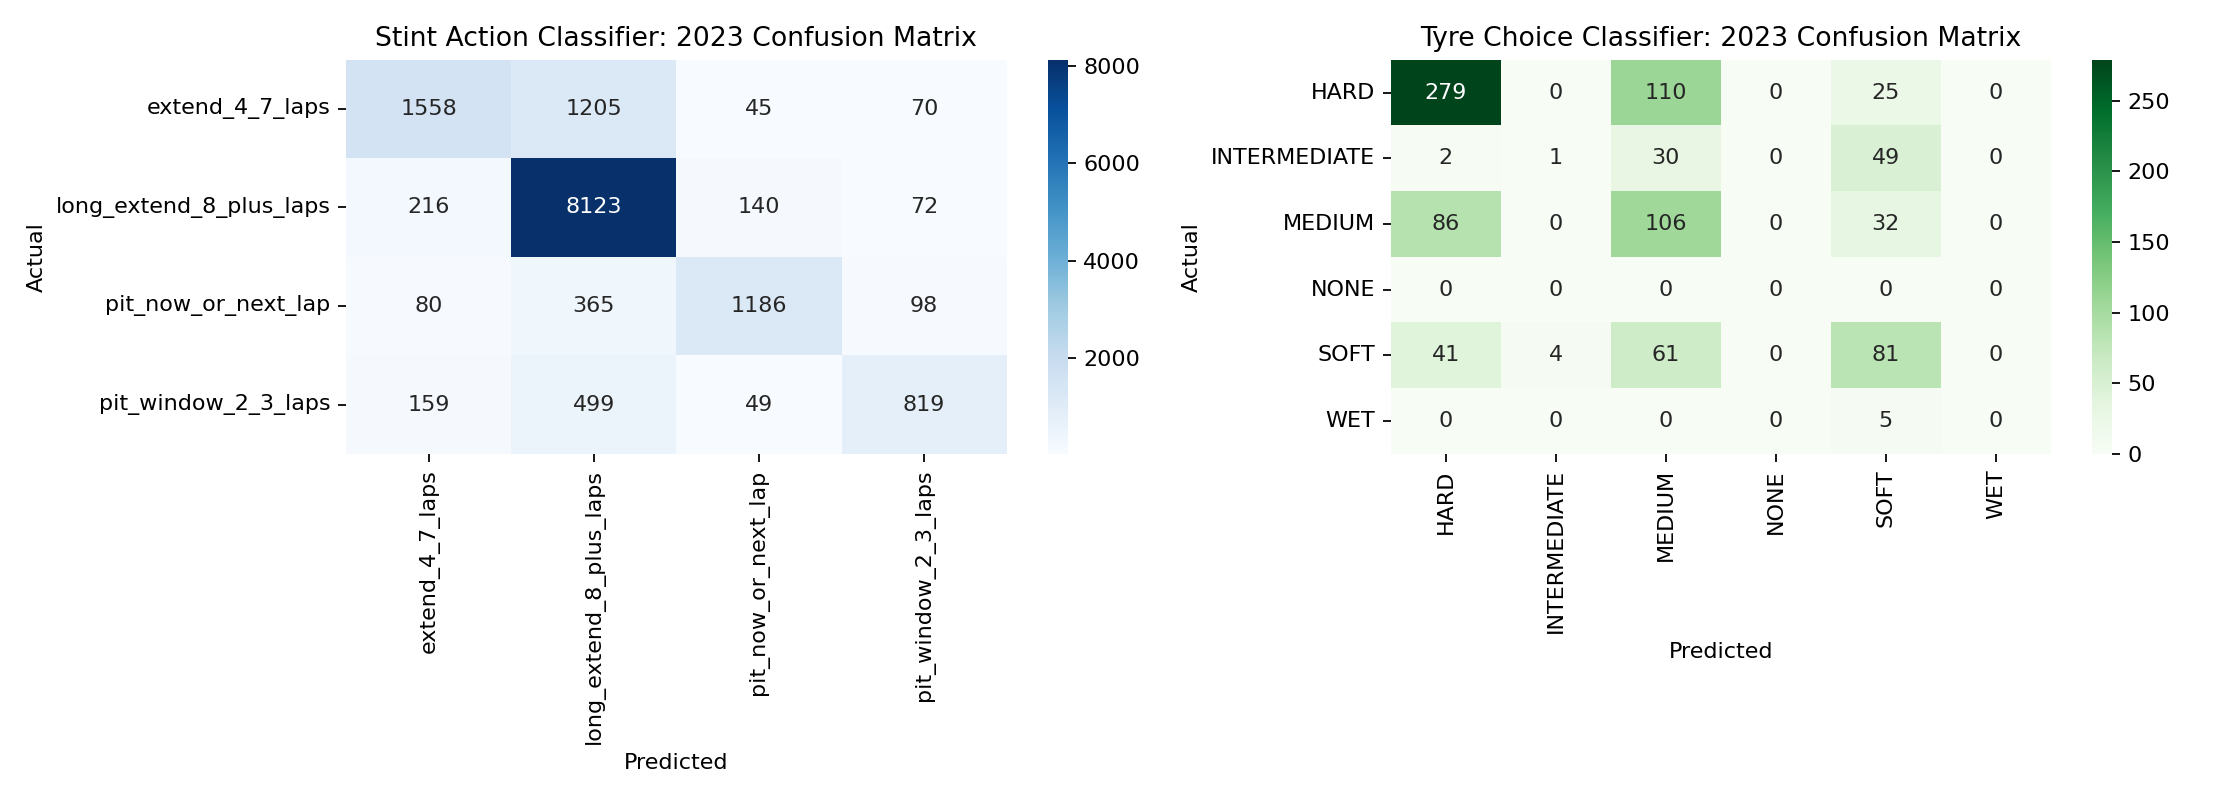

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/stint_remaining_regression_holdout.png exists: True


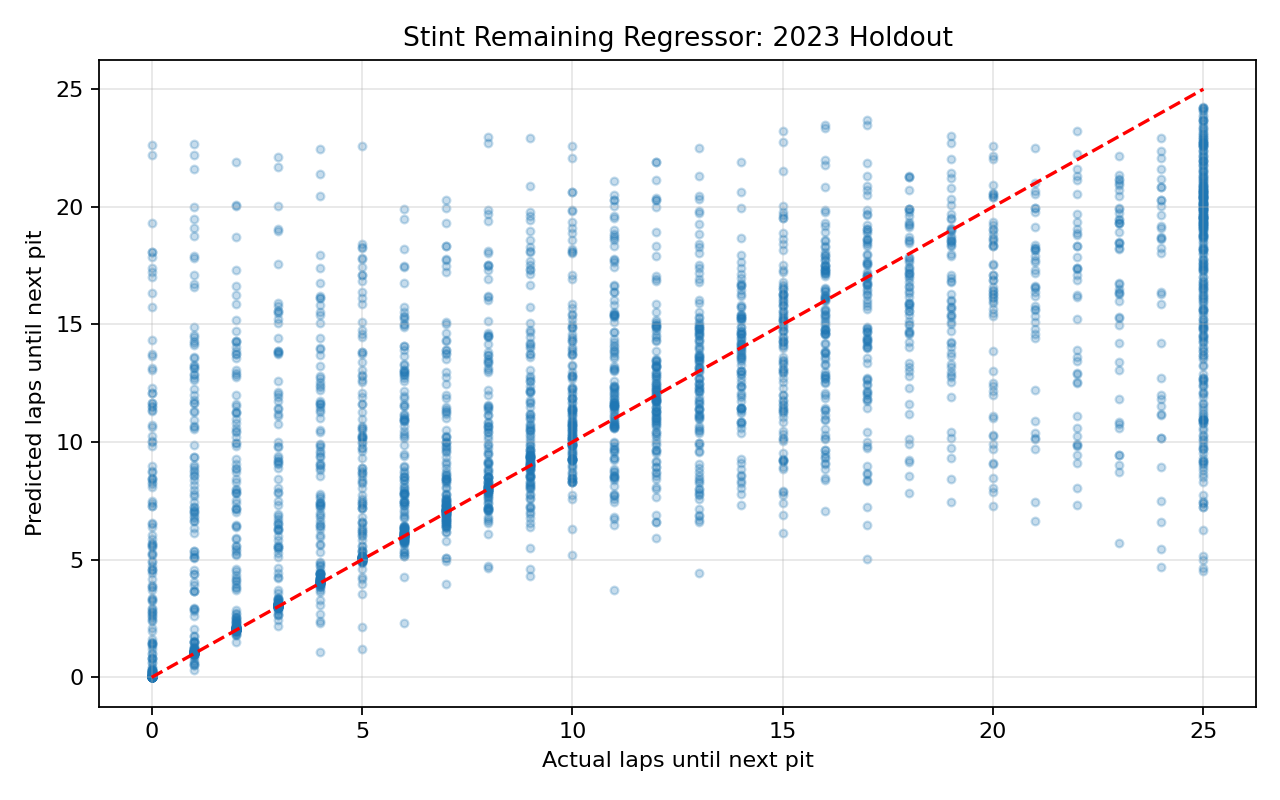

In [4]:
from pathlib import Path
from IPython.display import Markdown, Image, display
import pandas as pd

ROOT = Path("/content/drive/MyDrive/ibm_project_stuff/MDCE")
REPORT_DIR = ROOT / "outputs" / "reports"
CHART_DIR = ROOT / "outputs" / "charts"

summary_md = REPORT_DIR / "mdce_real_multidecision_training_summary.md"
registry_csv = REPORT_DIR / "mdce_real_decision_training_registry.csv"
print("Summary:", summary_md)
print("Registry:", registry_csv)
display(Markdown(summary_md.read_text(encoding="utf-8")))
display(pd.read_csv(registry_csv))

for chart in ["real_multidecision_confusion_matrices.png", "stint_remaining_regression_holdout.png"]:
    path = CHART_DIR / chart
    print("Chart:", path, "exists:", path.exists())
    if path.exists():
        display(Image(filename=str(path)))


## 5. What To Send Back

Send these back in chat after it finishes:

- The `REAL MULTIDECISION TRAINING COMPLETE` block.
- The displayed `mdce_real_multidecision_training_summary.md`.
- The `mdce_real_decision_training_registry.csv` table.
- Any error traceback if it stops.
